In [1]:
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121
Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.version.cuda)

2.10.0+cu128
True
12.8


# 🤖 AI vs Human Text Classification
## Pipeline: DistilBERT → MLP Classifier

**Dataset:** [AI vs Human Text Dataset — Kaggle](https://www.kaggle.com/datasets/muqaddasejaz/ai-vs-human-text-dataset)  
**Task:** Binary classification — membedakan teks yang ditulis AI (label=1) vs manusia (label=0)  
**Pipeline:**
```
Raw Text
   ↓
Preprocessing (cleaning, normalisasi)
   ↓
Exploratory Data Analysis (EDA)
   ↓
DistilBERT Tokenizer + Feature Extraction ([CLS] embeddings)
   ↓
MLP Classifier
   ↓
Evaluation & Interpretasi
```

---
## 📦 1. Setup & Instalasi Library

In [3]:
# Install dependencies (jalankan sekali saja)
%pip install transformers scikit-learn pandas numpy matplotlib seaborn wordcloud nltk tqdm -q

Note: you may need to restart the kernel to use updated packages.


In [4]:
# ── Core Libraries ──
import os
import re
import warnings
import numpy as np
import pandas as pd

# ── Visualisasi ──
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from wordcloud import WordCloud

# ── NLP ──
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import Counter

# ── Transformers (DistilBERT) ──
import torch
from torch.utils.data import DataLoader, TensorDataset
from transformers import DistilBertTokenizerFast, DistilBertModel

# ── Machine Learning ──
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_curve, auc,
    ConfusionMatrixDisplay
)

# ── Tqdm ──
from tqdm import tqdm

warnings.filterwarnings('ignore')

# ── Download NLTK resources ──
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

# ── Config ──
SEED       = 42
DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'
MAX_LEN    = 512      # panjang token maksimum DistilBERT
BATCH_SIZE = 32       # sesuaikan dengan VRAM / RAM
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Palette ──
PALETTE = {'Human': '#4C72B0', 'AI': '#DD8452'}

print(f"✅ Device : {DEVICE}")
print(f"✅ PyTorch: {torch.__version__}")

✅ Device : cuda
✅ PyTorch: 2.10.0+cu128


---
## 📂 2. Load Dataset

In [5]:
# ── Load Data ──
# Ubah path sesuai lokasi file hasil download dari Kaggle
DATA_PATH = '/kaggle/input/datasets/hubertcendana/ai-human-multi/AI_Human_MultiSource.csv'   # ← sesuaikan nama file

df = pd.read_csv(DATA_PATH)
print(f"Shape  : {df.shape}")
print(f"Kolom  : {df.columns.tolist()}")
df.head()

Shape  : (512602, 4)
Kolom  : ['text', 'label', 'domain', 'source']


,text,label,domain,source
0,Imane Merga Jida (ኢማነ መርጋ ጂዳ) (born 15 October...,0,general,GPT_wiki_intro
1,Having a positive attitude is essential for su...,1,general,AI_Human_Final
2,Phone & Driving Using cell phones while drivin...,0,society,AI_Human_Final
3,"Delaware Stadium is a 18,800-seat multi-purpos...",1,education,GPT_wiki_intro
4,Small RNA sequencing (Small RNA-Seq) is a type...,0,society,GPT_wiki_intro


In [6]:
# ── Standarisasi nama kolom ──
# Dataset biasanya punya kolom 'text' dan 'generated' (0=Human, 1=AI)
# Rename jika perlu:
df.columns = df.columns.str.strip().str.lower()

# Periksa nama kolom yang ada
print("Kolom tersedia:", df.columns.tolist())

# Jika nama berbeda, ganti manual:
# df = df.rename(columns={'your_text_col': 'text', 'your_label_col': 'generated'})

TEXT_COL  = 'text'
LABEL_COL = 'label'   # 0 = Human, 1 = AI

df = df[[TEXT_COL, LABEL_COL]].copy()
df.columns = ['text', 'label']
df['label_name'] = df['label'].map({0: 'Human', 1: 'AI'})
df.head()

Kolom tersedia: ['text', 'label', 'domain', 'source']


,text,label,label_name
0,Imane Merga Jida (ኢማነ መርጋ ጂዳ) (born 15 October...,0,Human
1,Having a positive attitude is essential for su...,1,AI
2,Phone & Driving Using cell phones while drivin...,0,Human
3,"Delaware Stadium is a 18,800-seat multi-purpos...",1,AI
4,Small RNA sequencing (Small RNA-Seq) is a type...,0,Human


In [7]:
# ── Info dasar ──
print("=" * 50)
print("INFO DATASET")
print("=" * 50)
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())
print("\nDistribusi label:")
print(df['label_name'].value_counts())

INFO DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 512602 entries, 0 to 512601
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   text        512602 non-null  object
 1   label       512602 non-null  int64 
 2   label_name  512602 non-null  object
dtypes: int64(1), object(2)
memory usage: 11.7+ MB
None

Missing values:
text          0
label         0
label_name    0
dtype: int64

Distribusi label:
label_name
Human    256301
AI       256301
Name: count, dtype: int64


---
## 🔧 3. Preprocessing

> **Catatan Penting:**  
> Untuk pipeline DistilBERT, kita menggunakan **dua versi teks**:
> - `text_clean` → untuk EDA (word cloud, n-gram, statistik)
> - `text` asli (minimal cleaning) → **input ke DistilBERT tokenizer** agar informasi kontekstual tetap terjaga

In [8]:
# Tambah sebelum apply preprocessing, untuk compare before/after
html_before = df['text'].astype(str).str.contains(r'<[a-zA-Z/]', regex=True)
print(f"Teks dengan HTML tags (sebelum cleaning): {html_before.sum():,}")
print(df[html_before].groupby('label_name').size())
# Harusnya: Human=57929, AI=179

Teks dengan HTML tags (sebelum cleaning): 30
label_name
AI        3
Human    27
dtype: int64


In [9]:
def preprocess_for_eda(text: str) -> str:
    text = str(text).lower()

    text = re.sub(r'<br\s*/?>', ' ', text, flags=re.IGNORECASE)
    text = re.sub(r'<[^>]+>', ' ', text)

    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'@\w+|#\w+', ' ', text)

    text = re.sub(r'\btle\b', 'the', text)

    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\bbr\b', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text


def preprocess_for_bert(text: str) -> str:
    text = str(text)

    text = re.sub(r'<br\s*/?>', ' ', text, flags=re.IGNORECASE)
    text = re.sub(r'<[^>]+>', ' ', text)

    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'\bTLE\b', 'the', text, flags=re.IGNORECASE)
    text = re.sub(r'(.)\1{20,}', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text


print("🔧 Menerapkan preprocessing...")
df['text_clean'] = df['text'].apply(preprocess_for_eda)
df['text_bert']  = df['text'].apply(preprocess_for_bert)
df = df[df['text_bert'].str.split().str.len() >= 10].reset_index(drop=True)
print(f"Setelah filter noise: {len(df):,} baris")
print("✅ Selesai!")
print("\nContoh text asli:")
print(df['text'].iloc[0][:300])
print("\nSetelah EDA preprocessing:")
print(df['text_clean'].iloc[0][:300])
print("\nSetelah BERT preprocessing:")
print(df['text_bert'].iloc[0][:300])

🔧 Menerapkan preprocessing...
Setelah filter noise: 512,602 baris
✅ Selesai!

Contoh text asli:
Imane Merga Jida (ኢማነ መርጋ ጂዳ) (born 15 October 1988) is an Ethiopian professional long-distance runner who specializes in the 5000 and 10,000 metres. He won his first world title at the 2011 IAAF World Cross Country Championships. At the 2011 World Championships in Athletics he won the 10,000 m bron

Setelah EDA preprocessing:
imane merga jida born october is an ethiopian professional long distance runner who specializes in the and metres he won his first world title at the iaaf world cross country championships at the world championships in athletics he won the m bronze medal but he was disqualified in the m losing a sec

Setelah BERT preprocessing:
Imane Merga Jida (ኢማነ መርጋ ጂዳ) (born 15 October 1988) is an Ethiopian professional long-distance runner who specializes in the 5000 and 10,000 metres. He won his first world title at the 2011 IAAF World Cross Country Championships. At the 2011 Wo

In [10]:
# ── Hapus duplikat & teks kosong ──
n_before = len(df)
df = df.drop_duplicates(subset='text').reset_index(drop=True)
df = df[df['text_clean'].str.len() > 10].reset_index(drop=True)
print(f"Duplikat & teks kosong dihapus: {n_before - len(df)} baris")
print(f"Dataset bersih: {len(df)} baris")

Duplikat & teks kosong dihapus: 17 baris
Dataset bersih: 512585 baris


In [11]:
# ── Feature statistik teks ──
df['char_count']    = df['text'].apply(len)
df['word_count']    = df['text_clean'].apply(lambda x: len(x.split()))
df['sent_count'] = df['text'].apply(
    lambda x: len([s for s in re.split(r'[.!?]+', str(x)) if s.strip()])
)
df['avg_word_len']  = df['text_clean'].apply(
    lambda x: np.mean([len(w) for w in x.split()]) if x.split() else 0
)
df['unique_words']  = df['text_clean'].apply(lambda x: len(set(x.split())))
df['lexical_rich']  = df['unique_words'] / (df['word_count'] + 1e-6)  # type-token ratio

df[['word_count', 'char_count', 'sent_count', 'avg_word_len', 'lexical_rich']].describe().round(2)

,word_count,char_count,sent_count,avg_word_len,lexical_rich
count,512585.00,512585.00,512585.00,512585.00,512585.00
mean,234.07,1411.25,12.77,4.80,0.55
std,138.13,835.17,7.61,0.47,0.11
min,3.00,106.00,1.00,1.00,0.01
25%,147.00,886.00,7.00,4.50,0.47
50%,194.00,1188.00,11.00,4.78,0.56
75%,303.00,1807.00,17.00,5.08,0.63
max,1120.00,8004.00,261.00,12.96,1.00


---
## 📊 4. Exploratory Data Analysis (EDA)

In [12]:
# Tambah sebelum apply preprocessing, untuk compare before/after
html_after = df['text_clean'].astype(str).str.contains(r'<[a-zA-Z/]', regex=True)
print(f"Teks dengan HTML tags (setelah cleaning): {html_after.sum():,}")
print(df[html_after].groupby('label_name').size())

Teks dengan HTML tags (setelah cleaning): 0
Series([], dtype: int64)


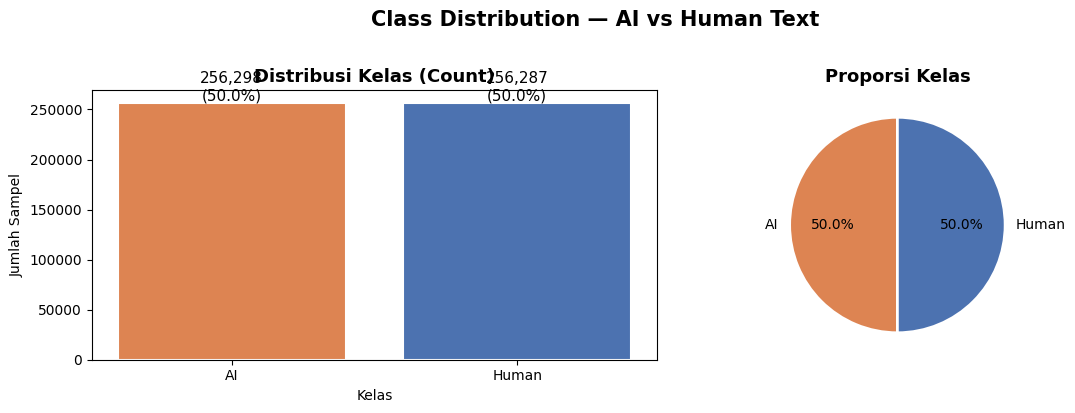

In [13]:
# ──────────────────────────────────────────────────
# 4.1 Distribusi Kelas
# ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
vc = df['label_name'].value_counts()
axes[0].bar(vc.index, vc.values,
            color=[PALETTE[k] for k in vc.index], edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribusi Kelas (Count)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Kelas'); axes[0].set_ylabel('Jumlah Sampel')
for i, (k, v) in enumerate(zip(vc.index, vc.values)):
    axes[0].text(i, v + 50, f'{v:,}\n({v/len(df)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=11)

# Pie chart
axes[1].pie(vc.values, labels=vc.index, autopct='%1.1f%%',
            colors=[PALETTE[k] for k in vc.index],
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Proporsi Kelas', fontsize=13, fontweight='bold')

plt.suptitle('Class Distribution — AI vs Human Text', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_class_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

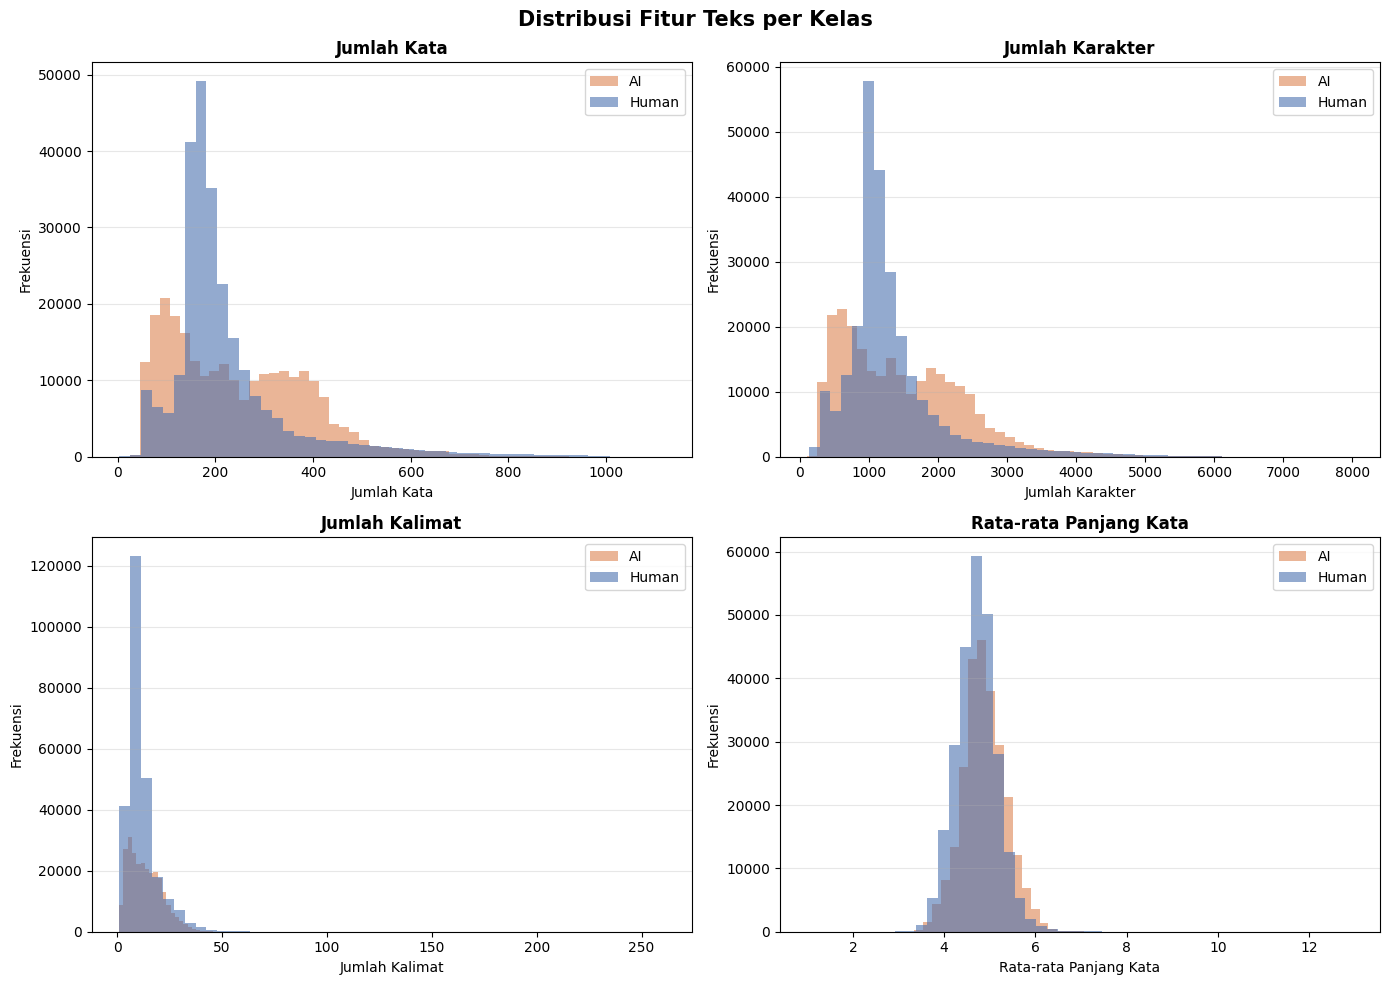

In [14]:
# ──────────────────────────────────────────────────
# 4.2 Distribusi Panjang Teks
# ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = [
    ('word_count',   'Jumlah Kata'),
    ('char_count',   'Jumlah Karakter'),
    ('sent_count',   'Jumlah Kalimat'),
    ('avg_word_len', 'Rata-rata Panjang Kata'),
]

for ax, (col, title) in zip(axes.flatten(), metrics):
    for label, grp in df.groupby('label_name'):
        ax.hist(grp[col], bins=50, alpha=0.6, label=label,
                color=PALETTE[label], edgecolor='none')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(title)
    ax.set_ylabel('Frekuensi')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Distribusi Fitur Teks per Kelas', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_text_length_dist.png', bbox_inches='tight', dpi=150)
plt.show()

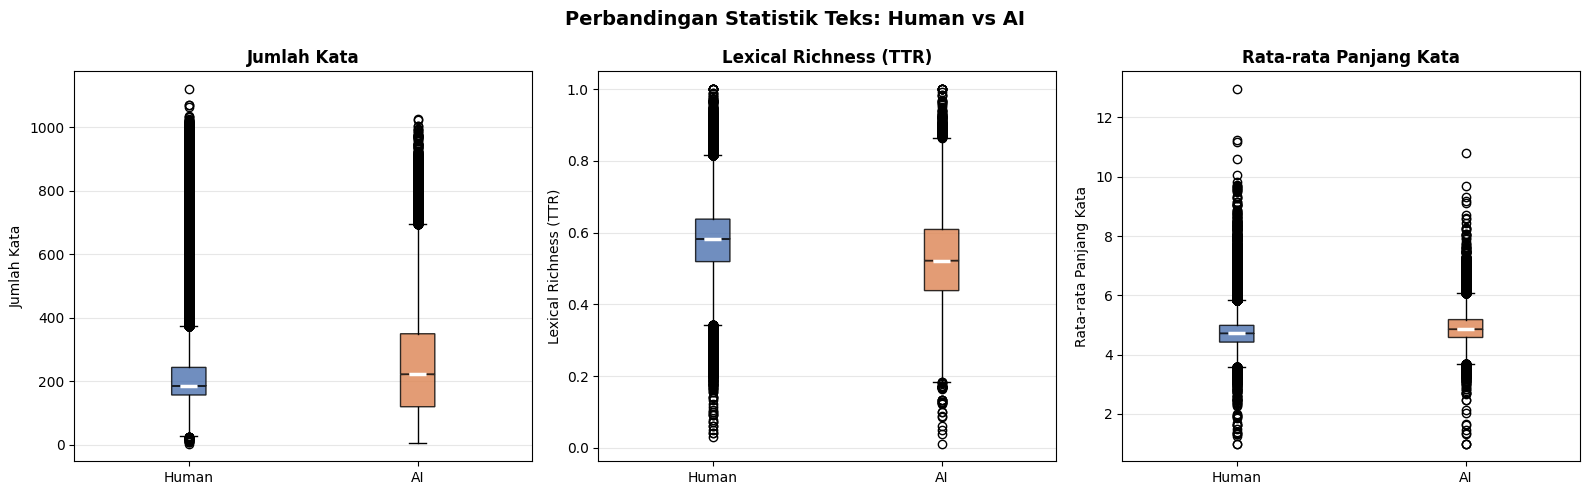

In [15]:
# ──────────────────────────────────────────────────
# 4.3 Box Plot Perbandingan Statistik per Kelas
# ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

box_metrics = ['word_count', 'lexical_rich', 'avg_word_len']
box_titles  = ['Jumlah Kata', 'Lexical Richness (TTR)', 'Rata-rata Panjang Kata']

for ax, col, title in zip(axes, box_metrics, box_titles):
    data_plot = [df[df['label_name'] == lb][col].values for lb in ['Human', 'AI']]
    bp = ax.boxplot(data_plot, labels=['Human', 'AI'], patch_artist=True, notch=True,
                    medianprops=dict(color='white', linewidth=2.5))
    for patch, color in zip(bp['boxes'], PALETTE.values()):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(title)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Perbandingan Statistik Teks: Human vs AI', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_boxplot.png', bbox_inches='tight', dpi=150)
plt.show()

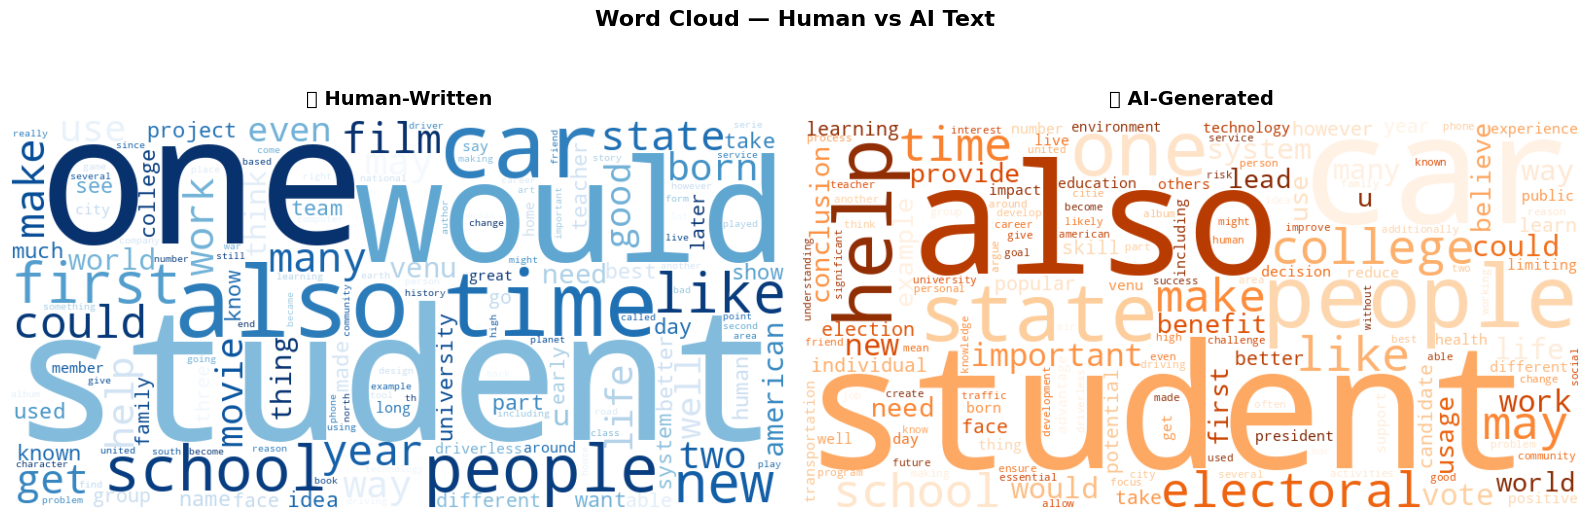

In [16]:
# ──────────────────────────────────────────────────
# 4.4 Word Cloud
# ──────────────────────────────────────────────────
stop_words = set(stopwords.words('english'))

def make_wordcloud(texts, title, color, ax):
    corpus = ' '.join(texts)
    wc = WordCloud(
        width=800, height=400,
        background_color='white',
        colormap=color,
        stopwords=stop_words,
        max_words=150,
        collocations=False
    ).generate(corpus)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=12)
    ax.axis('off')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
make_wordcloud(df[df['label']==0]['text_clean'], '🧑 Human-Written', 'Blues',   axes[0])
make_wordcloud(df[df['label']==1]['text_clean'], '🤖 AI-Generated',  'Oranges', axes[1])

plt.suptitle('Word Cloud — Human vs AI Text', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_wordcloud.png', bbox_inches='tight', dpi=150)
plt.show()

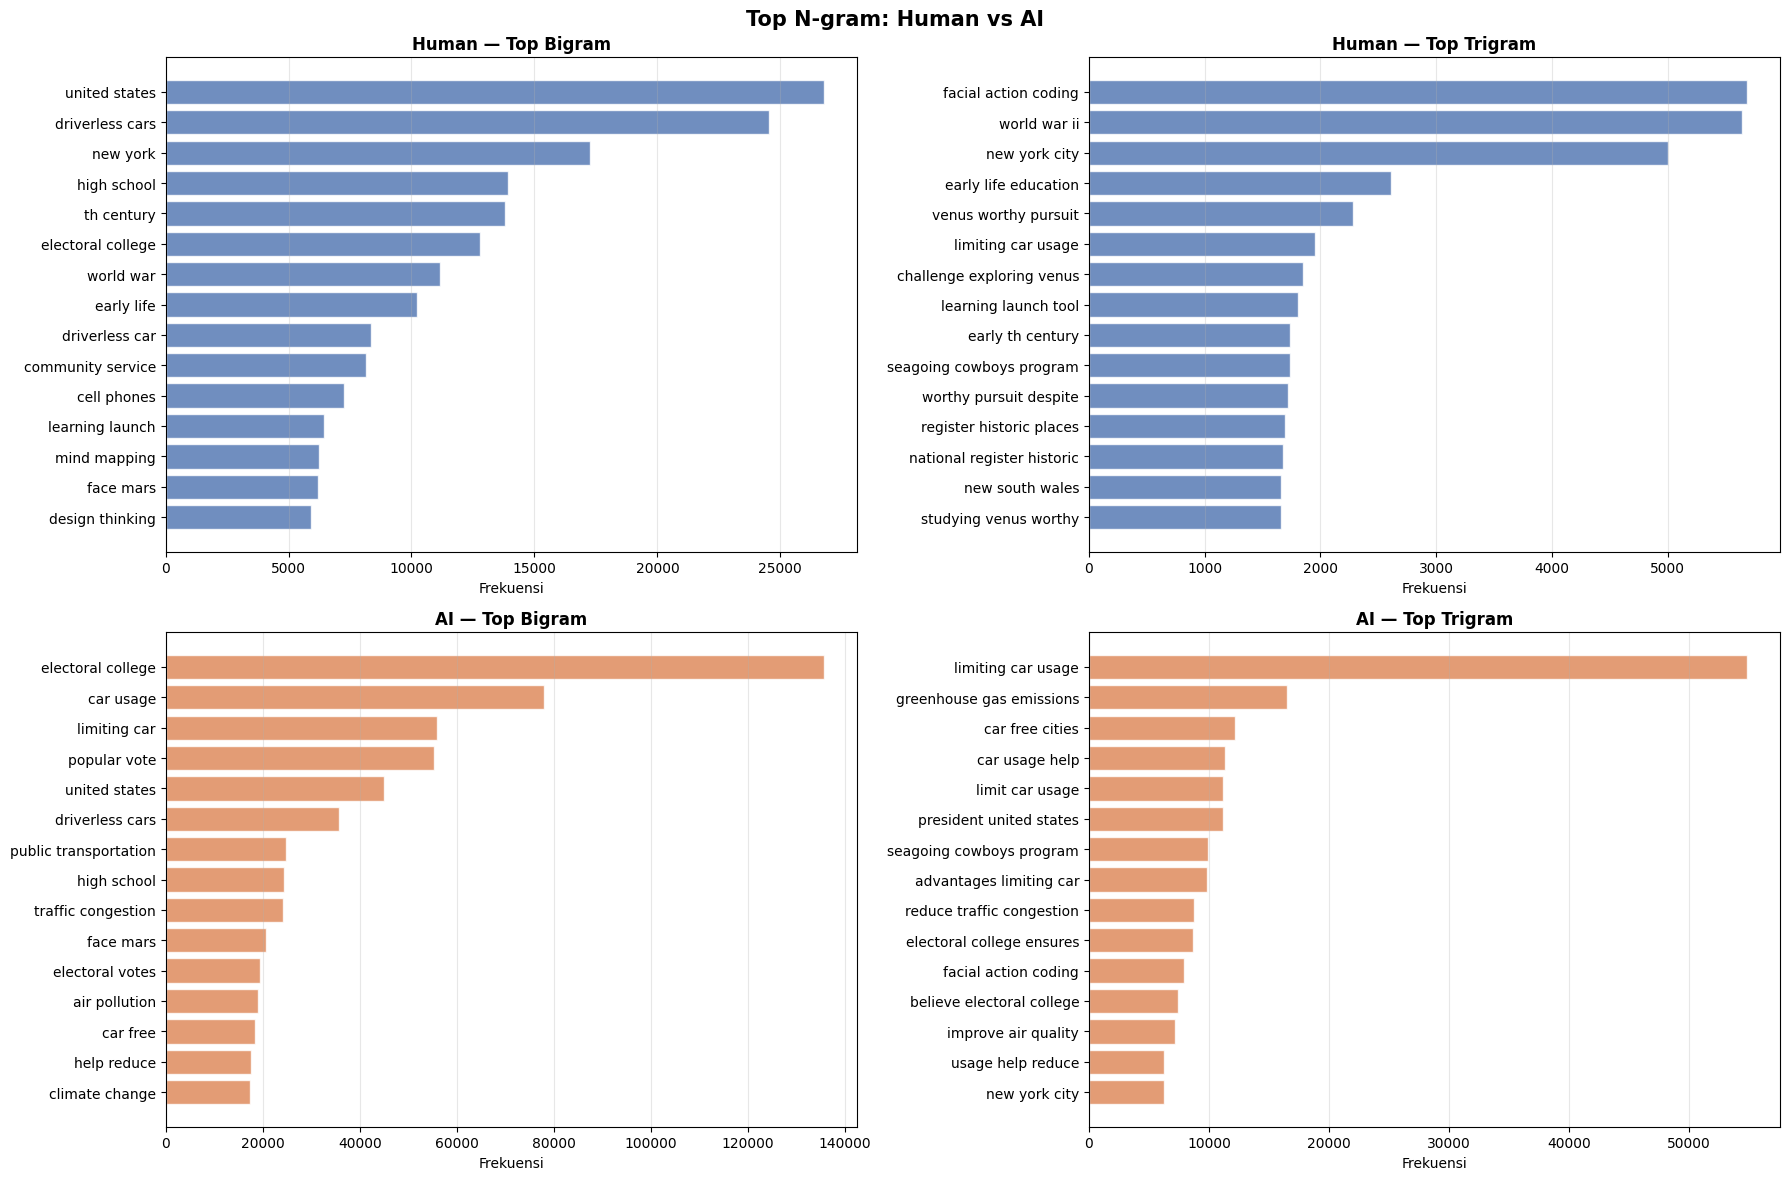

In [17]:
# ──────────────────────────────────────────────────
# 4.5 Top N-gram (Bigram & Trigram)
# ──────────────────────────────────────────────────
from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngrams(corpus, n=2, top_k=15):
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english', max_features=10000)
    bag = vec.fit_transform(corpus)
    sum_words = bag.sum(axis=0)
    words_freq = [(word, sum_words[0, idx])
                  for word, idx in vec.vocabulary_.items()]
    return sorted(words_freq, key=lambda x: x[1], reverse=True)[:top_k]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

for row_idx, label in enumerate([0, 1]):
    label_name = 'Human' if label == 0 else 'AI'
    color      = PALETTE[label_name]
    subset     = df[df['label'] == label]['text_clean'].tolist()

    for col_idx, n in enumerate([2, 3]):
        ngrams = get_top_ngrams(subset, n=n, top_k=15)
        words, freqs = zip(*ngrams)
        ax = axes[row_idx][col_idx]
        ax.barh(range(len(words)), freqs, color=color, alpha=0.8, edgecolor='white')
        ax.set_yticks(range(len(words)))
        ax.set_yticklabels(words, fontsize=10)
        ax.invert_yaxis()
        ax.set_title(f'{label_name} — Top {"Bigram" if n==2 else "Trigram"}',
                     fontsize=12, fontweight='bold')
        ax.set_xlabel('Frekuensi')
        ax.grid(axis='x', alpha=0.3)

plt.suptitle('Top N-gram: Human vs AI', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_ngrams.png', bbox_inches='tight', dpi=150)
plt.show()

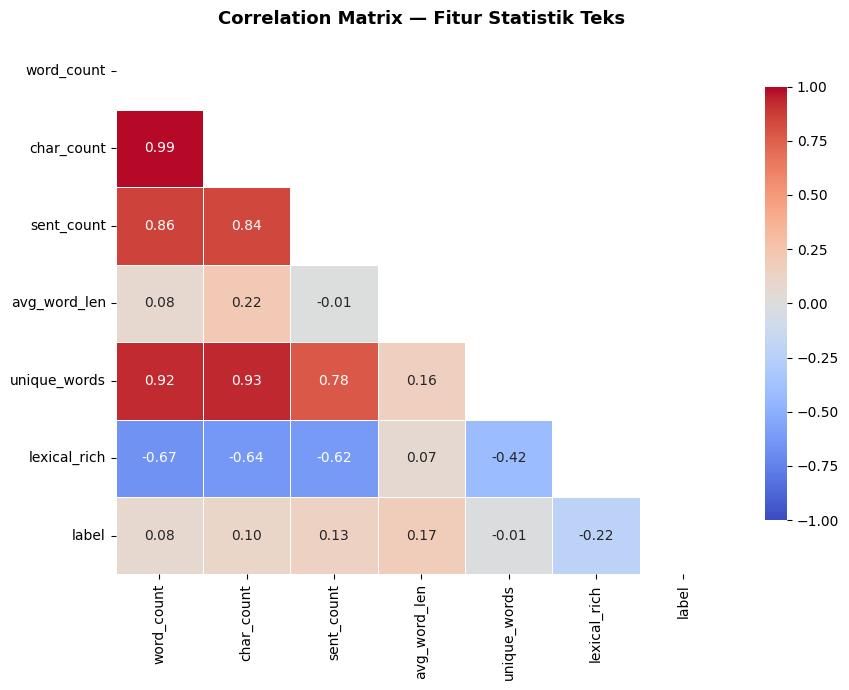

In [18]:
# ──────────────────────────────────────────────────
# 4.6 Korelasi Fitur Statistik
# ──────────────────────────────────────────────────
feat_cols = ['word_count', 'char_count', 'sent_count',
             'avg_word_len', 'unique_words', 'lexical_rich', 'label']

fig, ax = plt.subplots(figsize=(9, 7))
corr = df[feat_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, linecolor='white',
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix — Fitur Statistik Teks', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation.png', bbox_inches='tight', dpi=150)
plt.show()

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (625 > 512). Running this sequence through the model will result in indexing errors


⏳ Menghitung panjang token (sample 2000 data)...
Persentase teks > 512 token (akan di-truncate): 9.5%
Statistik token length:
count    2000.0
mean      303.3
std       163.1
min        57.0
25%       195.0
50%       268.0
75%       387.2
max      1181.0
Name: text_bert, dtype: float64


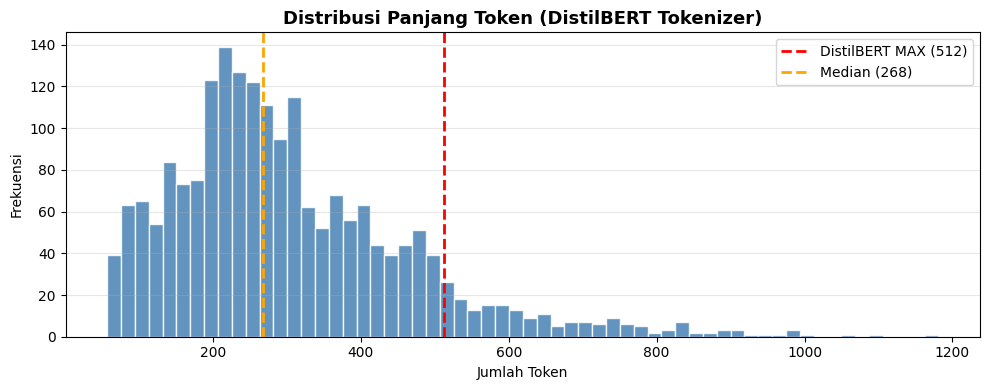

In [19]:
# ──────────────────────────────────────────────────
# 4.7 Distribusi Panjang Token (penting untuk DistilBERT MAX_LEN)
# ──────────────────────────────────────────────────
tokenizer_check = DistilBertTokenizerFast.from_pretrained('distilbert-base-cased')

print("⏳ Menghitung panjang token (sample 2000 data)...")
sample_df = df.sample(min(2000, len(df)), random_state=SEED)

token_lengths = sample_df['text_bert'].fillna('').astype(str).apply(
    lambda x: len(tokenizer_check(
        x,
        add_special_tokens=True,
        truncation=False
    )['input_ids'])
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(token_lengths, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(512, color='red', linestyle='--', linewidth=2, label='DistilBERT MAX (512)')
ax.axvline(token_lengths.median(), color='orange', linestyle='--', linewidth=2,
           label=f'Median ({token_lengths.median():.0f})')
ax.set_title('Distribusi Panjang Token (DistilBERT Tokenizer)', fontsize=13, fontweight='bold')
ax.set_xlabel('Jumlah Token')
ax.set_ylabel('Frekuensi')
ax.legend()
ax.grid(axis='y', alpha=0.3)

pct_over_512 = (token_lengths > 512).mean() * 100
print(f"Persentase teks > 512 token (akan di-truncate): {pct_over_512:.1f}%")
print(f"Statistik token length:\n{token_lengths.describe().round(1)}")

plt.tight_layout()
plt.savefig('eda_token_length.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 🤗 5. DistilBERT Feature Extraction

Strategi: Gunakan **[CLS] token embedding** dari DistilBERT sebagai representasi teks → feed ke MLP.  
Kita **freeze** DistilBERT (tidak fine-tune) → lebih cepat dan efisien memori.

In [20]:
# ── Load DistilBERT ──
MODEL_NAME = 'distilbert-base-cased'
tokenizer  = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)
bert_model = DistilBertModel.from_pretrained(MODEL_NAME)
bert_model = bert_model.to(DEVICE)
bert_model.eval()

print(f"✅ DistilBERT loaded → {DEVICE}")
print(f"   Total parameters: {sum(p.numel() for p in bert_model.parameters()):,}")

config.json:   0%|          | 0.00/465 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/263M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-cased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ DistilBERT loaded → cuda
   Total parameters: 65,190,912


In [21]:
def extract_cls_embeddings(texts, tokenizer, model,
                           max_len=512, batch_size=32):
    """
    Ekstrak [CLS] token embedding dari DistilBERT.
    Output shape: (N, 768)
    """
    all_embeddings = []
    model.eval()

    for i in tqdm(range(0, len(texts), batch_size), desc='Extracting embeddings'):
        batch_texts = texts[i: i + batch_size]

        encoded = tokenizer(
            batch_texts,
            max_length=max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        input_ids      = encoded['input_ids'].to(DEVICE)
        attention_mask = encoded['attention_mask'].to(DEVICE)

        with torch.no_grad():
            outputs = model(input_ids=input_ids,
                            attention_mask=attention_mask)

        # [CLS] token = index 0 dari last hidden state
        cls_embeddings = outputs.last_hidden_state[:, 0, :]  # (batch, 768)
        all_embeddings.append(cls_embeddings.cpu().numpy())

    return np.vstack(all_embeddings)


print("⏳ Mengekstrak CLS embeddings... (bisa makan waktu beberapa menit)")
texts_list = df['text_bert'].tolist()
X = extract_cls_embeddings(texts_list, tokenizer, bert_model,
                           max_len=MAX_LEN, batch_size=BATCH_SIZE)
y = df['label'].values

print(f"\n✅ Embedding shape: {X.shape}")
print(f"   Label shape    : {y.shape}")

⏳ Mengekstrak CLS embeddings... (bisa makan waktu beberapa menit)


Extracting embeddings: 100%|██████████| 16019/16019 [2:25:44<00:00,  1.83it/s]



✅ Embedding shape: (512585, 768)
   Label shape    : (512585,)


---
## ✂️ 6. Train / Validation / Test Split

In [22]:
# ── Split: 70% train | 15% val | 15% test ──
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print(f"Train : {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Val   : {X_val.shape[0]:,}   samples ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test  : {X_test.shape[0]:,}  samples ({X_test.shape[0]/len(X)*100:.1f}%)")

Train : 358,809 samples (70.0%)
Val   : 76,888   samples (15.0%)
Test  : 76,888  samples (15.0%)


---
## 🧠 7. MLP Classifier

In [23]:
# ── Definisi MLP ──
# Arsitektur: 768 → 512 → 256 → 128 → 2
from sklearn.utils.class_weight import compute_sample_weight
mlp = MLPClassifier(
    hidden_layer_sizes=(512, 256, 128),
    activation='relu',
    solver='adam',
    alpha=1e-4,                # L2 regularization
    batch_size=64,
    learning_rate='adaptive',
    learning_rate_init=1e-3,
    max_iter=30,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=SEED,
    verbose=True
)

print("🧠 Training MLP...")
mlp.fit(X_train, y_train) 
print("\n✅ Training selesai!")

🧠 Training MLP...
Iteration 1, loss = 0.17772363
Validation score: 0.955464
Iteration 2, loss = 0.12142342
Validation score: 0.961177
Iteration 3, loss = 0.10695610
Validation score: 0.961512
Iteration 4, loss = 0.09757710
Validation score: 0.966779
Iteration 5, loss = 0.09100795
Validation score: 0.968284
Iteration 6, loss = 0.08636395
Validation score: 0.965107
Iteration 7, loss = 0.08296811
Validation score: 0.962404
Iteration 8, loss = 0.07969210
Validation score: 0.969566
Iteration 9, loss = 0.07713948
Validation score: 0.968646
Iteration 10, loss = 0.07474110
Validation score: 0.974304
Iteration 11, loss = 0.07269802
Validation score: 0.969622
Iteration 12, loss = 0.07151817
Validation score: 0.972715
Iteration 13, loss = 0.06967222
Validation score: 0.963630
Iteration 14, loss = 0.06750480
Validation score: 0.973663
Iteration 15, loss = 0.06653068
Validation score: 0.971935
Iteration 16, loss = 0.06512150
Validation score: 0.973496
Iteration 17, loss = 0.06411710
Validation scor

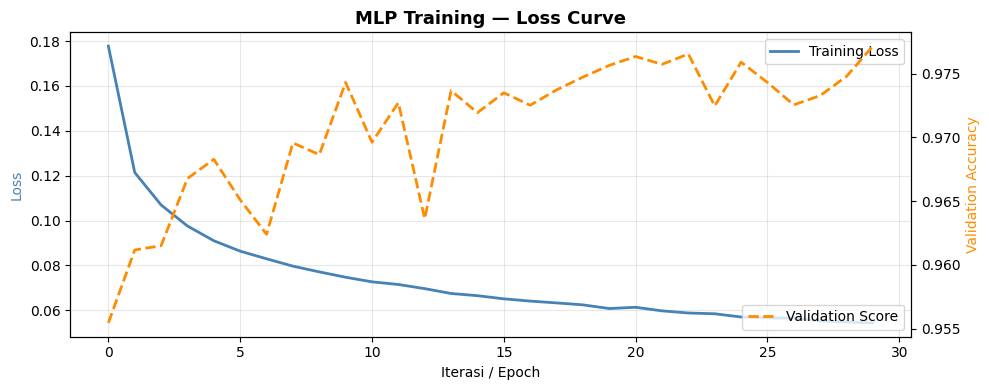

In [24]:
# ── Plot Loss Curve ──
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(mlp.loss_curve_, label='Training Loss', color='steelblue', linewidth=2)
if hasattr(mlp, 'validation_scores_') and mlp.validation_scores_ is not None:
    ax2 = ax.twinx()
    ax2.plot(mlp.validation_scores_, label='Validation Score',
             color='darkorange', linewidth=2, linestyle='--')
    ax2.set_ylabel('Validation Accuracy', color='darkorange')
    ax2.legend(loc='lower right')

ax.set_title('MLP Training — Loss Curve', fontsize=13, fontweight='bold')
ax.set_xlabel('Iterasi / Epoch')
ax.set_ylabel('Loss', color='steelblue')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('mlp_loss_curve.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 📈 8. Evaluasi Model

In [25]:
# ── Prediksi ──
y_pred_val  = mlp.predict(X_val)
y_pred_test = mlp.predict(X_test)
y_prob_test = mlp.predict_proba(X_test)[:, 1]

print("=" * 55)
print("VALIDATION SET")
print("=" * 55)
print(classification_report(y_val, y_pred_val,
                             target_names=['Human', 'AI']))

print("=" * 55)
print("TEST SET")
print("=" * 55)
print(classification_report(y_test, y_pred_test,
                             target_names=['Human', 'AI']))

VALIDATION SET
              precision    recall  f1-score   support

       Human       0.97      0.98      0.98     38443
          AI       0.98      0.97      0.98     38445

    accuracy                           0.98     76888
   macro avg       0.98      0.98      0.98     76888
weighted avg       0.98      0.98      0.98     76888

TEST SET
              precision    recall  f1-score   support

       Human       0.97      0.98      0.98     38443
          AI       0.98      0.97      0.98     38445

    accuracy                           0.98     76888
   macro avg       0.98      0.98      0.98     76888
weighted avg       0.98      0.98      0.98     76888



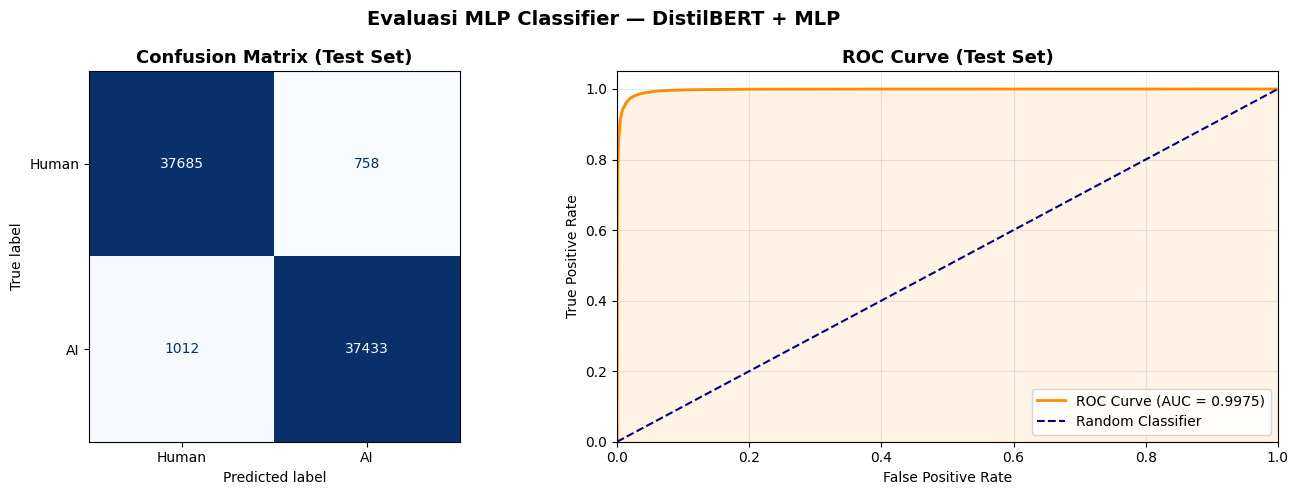

Test Accuracy : 0.9770
ROC-AUC       : 0.9975


In [26]:
# ── Confusion Matrix & ROC Curve ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Human', 'AI'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix (Test Set)', fontsize=13, fontweight='bold')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
roc_auc_val = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='darkorange', lw=2,
             label=f'ROC Curve (AUC = {roc_auc_val:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--',
             label='Random Classifier')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='darkorange')
axes[1].set_xlim([0.0, 1.0]); axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve (Test Set)', fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.suptitle('Evaluasi MLP Classifier — DistilBERT + MLP', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eval_confusion_roc.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"Test Accuracy : {accuracy_score(y_test, y_pred_test):.4f}")
print(f"ROC-AUC       : {roc_auc_val:.4f}")

In [27]:
# ──────────────────────────────────────────────────
# 8.3 Error Analysis — Contoh Salah Prediksi
# ──────────────────────────────────────────────────
test_indices = df.index[
    (df.index < len(df))
].tolist()[:len(y_test)]  # hanya sebagai placeholder indeks

idx = np.arange(len(df))

idx_train, idx_temp, y_train, y_temp = train_test_split(
    idx, y, test_size=0.30, random_state=SEED, stratify=y
)

idx_val, idx_test, y_val, y_test = train_test_split(
    idx_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

X_train, X_val, X_test = X[idx_train], X[idx_val], X[idx_test]

test_df = df.iloc[idx_test].copy().reset_index(drop=True)
test_df['y_true'] = y_test
test_df['y_pred'] = y_pred_test

errors = test_df[test_df['y_true'] != test_df['y_pred']]
print(f"Jumlah error: {len(errors)} / {len(test_df)} ({len(errors)/len(test_df)*100:.1f}%)")
print("\n=== Contoh False Positive (Prediksi AI, Aslinya Human) ===")
fp = errors[errors['y_pred'] == 1][['text', 'y_true', 'y_pred']].head(3)
for _, row in fp.iterrows():
    print(f"\n→ {row['text'][:200]}...")

print("\n=== Contoh False Negative (Prediksi Human, Aslinya AI) ===")
fn = errors[errors['y_pred'] == 0][['text', 'y_true', 'y_pred']].head(3)
for _, row in fn.iterrows():
    print(f"\n→ {row['text'][:200]}...")

Jumlah error: 1770 / 76888 (2.3%)

=== Contoh False Positive (Prediksi AI, Aslinya Human) ===

→ "Los Pazos de Ulloa" is a novel by Emilia Pardo Bazán that was published in 1881. It is considered a cornerstone of Spanish Realist literature and is often compared to the works of Gustave Flaubert, É...

→ Sure! Here are some blog titles for how to build up an AI business: 1. "AI is booming - start your own business now." 2. "How to start a profitable AI business." 3. "How to make money using AI." 4. "M...

→ Methane does not affect the ozone layer in the stratosphere. Rather, methane decomposes into ozone when exposed to sunlight, and ozone is a pollutant that damages the respiratory system of human being...

=== Contoh False Negative (Prediksi Human, Aslinya AI) ===

→ Richard Harrison Lane (June 28, 1927 – September 5, 1998) was an American professional baseball player. He played nine seasons in Major League Baseball (MLB) for the New York Yankees (1951–1957), Milw...

→ Norman Bruce An

---
## 💾 9. Simpan Model & Embeddings

In [28]:
import pickle

# Simpan MLP
with open('db+mlp+delbr.pkl', 'wb') as f:
    pickle.dump(mlp, f)

# Simpan embeddings (opsional, untuk reuse)
np.save('distilbert_embeddings.npy', X)
np.save('labels.npy', y)

print("✅ Model & embeddings tersimpan!")

✅ Model & embeddings tersimpan!


---
## 🔍 10. Inference — Prediksi Teks Baru

In [29]:
def predict_text(text: str, tokenizer, bert_model, mlp_model,
                 max_len=512, device='cpu') -> dict:
    """
    Prediksi apakah teks ditulis oleh AI atau Human.
    """
    # Preprocessing minimal
    text_clean = preprocess_for_bert(text)

    # Tokenisasi
    encoded = tokenizer(
        text_clean,
        max_length=max_len,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    input_ids      = encoded['input_ids'].to(device)
    attention_mask = encoded['attention_mask'].to(device)

    # Ekstrak embedding
    bert_model.eval()
    with torch.no_grad():
        outputs = bert_model(input_ids=input_ids,
                             attention_mask=attention_mask)
    embedding = outputs.last_hidden_state[:, 0, :].cpu().numpy()

    # Prediksi
    pred       = mlp_model.predict(embedding)[0]
    prob       = mlp_model.predict_proba(embedding)[0]

    return {
        'prediction' : 'AI' if pred == 1 else 'Human',
        'prob_human' : round(prob[0] * 100, 2),
        'prob_ai'    : round(prob[1] * 100, 2),
        'confidence' : round(max(prob) * 100, 2)
    }


# ── Contoh Penggunaan ──
sample_texts = [
    """The development of artificial intelligence has raised profound questions 
    about the nature of consciousness and what it means to be human. As machines 
    become increasingly capable of performing tasks once thought to be uniquely 
    human, we must grapple with the philosophical and ethical implications.""",

    """I went to the market yesterday and it was super crowded lol. 
    Couldn't find parking for like 20 minutes. Grabbed some apples and bread, 
    totally forgot the milk again. Story of my life honestly."""
]

for i, text in enumerate(sample_texts, 1):
    result = predict_text(text, tokenizer, bert_model, mlp, MAX_LEN, DEVICE)
    print(f"\n📝 Teks #{i}:")
    print(f"   → {text[:100].strip()}...")
    print(f"   Prediksi  : {result['prediction']}")
    print(f"   P(Human)  : {result['prob_human']}%")
    print(f"   P(AI)     : {result['prob_ai']}%")
    print(f"   Confidence: {result['confidence']}%")


📝 Teks #1:
   → The development of artificial intelligence has raised profound questions 
    about the nature of co...
   Prediksi  : AI
   P(Human)  : 38.47999954223633%
   P(AI)     : 61.52000045776367%
   Confidence: 61.52000045776367%

📝 Teks #2:
   → I went to the market yesterday and it was super crowded lol. 
    Couldn't find parking for like 20...
   Prediksi  : Human
   P(Human)  : 99.93000030517578%
   P(AI)     : 0.07000000029802322%
   Confidence: 99.93000030517578%


---
## 📋 11. Ringkasan Hasil

| Komponen | Detail |
|---|---|
| **Feature Extractor** | DistilBERT-base-cased (frozen) |
| **Representasi** | [CLS] token embedding (dim=768) |
| **Classifier** | MLP: 768→512→256→128→2 |
| **Aktivasi** | ReLU + Softmax |
| **Optimizer** | Adam (lr=1e-3, adaptive) |
| **Regularisasi** | L2 (α=1e-4) + Early Stopping |
| **Split** | 70% train / 15% val / 15% test |

### 💡 Catatan & Next Steps

1. **Fine-tuning DistilBERT end-to-end** → biasanya memberikan performa lebih baik dari frozen embedding
2. **Mean pooling** seluruh hidden state (bukan hanya [CLS]) bisa dicoba sebagai alternatif
3. **Hyperparameter tuning MLP** dengan Optuna atau GridSearchCV
4. **Augmentasi data** untuk kelas yang lebih sedikit
5. **SHAP / LIME** untuk interpretabilitas model